  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  

SHAPE
(49068, 10)

MISSING VALUES
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                

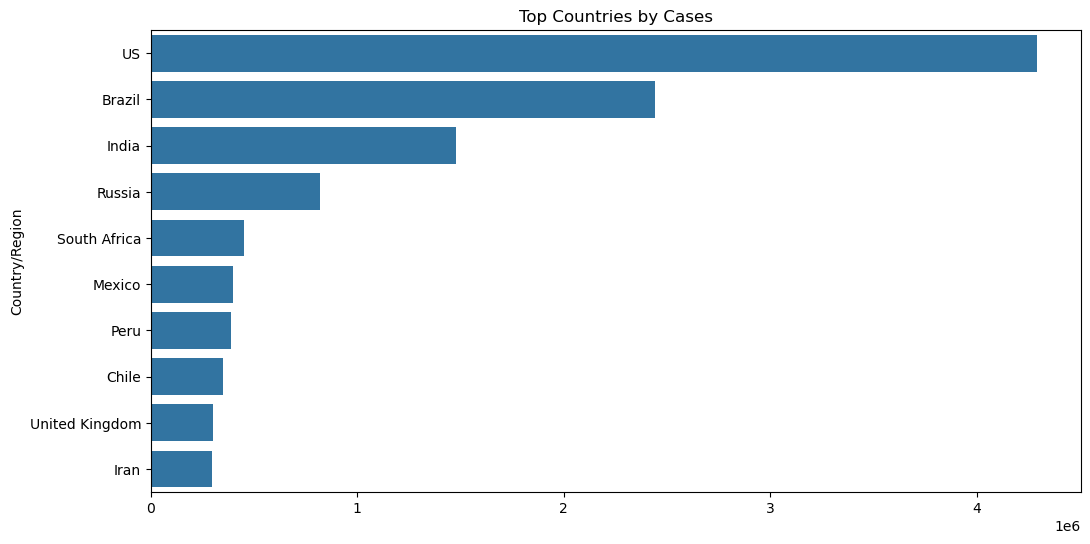

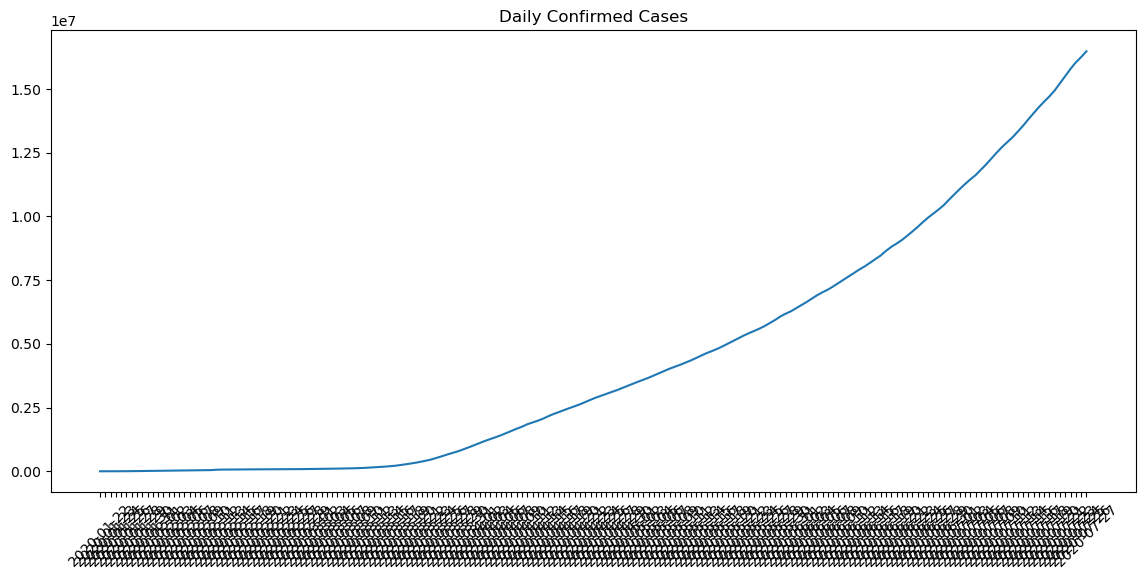

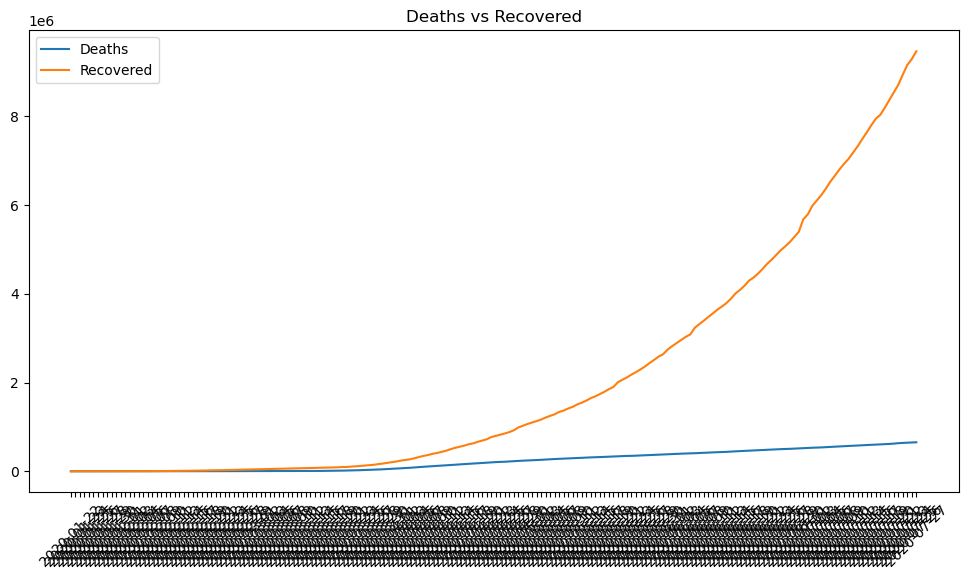

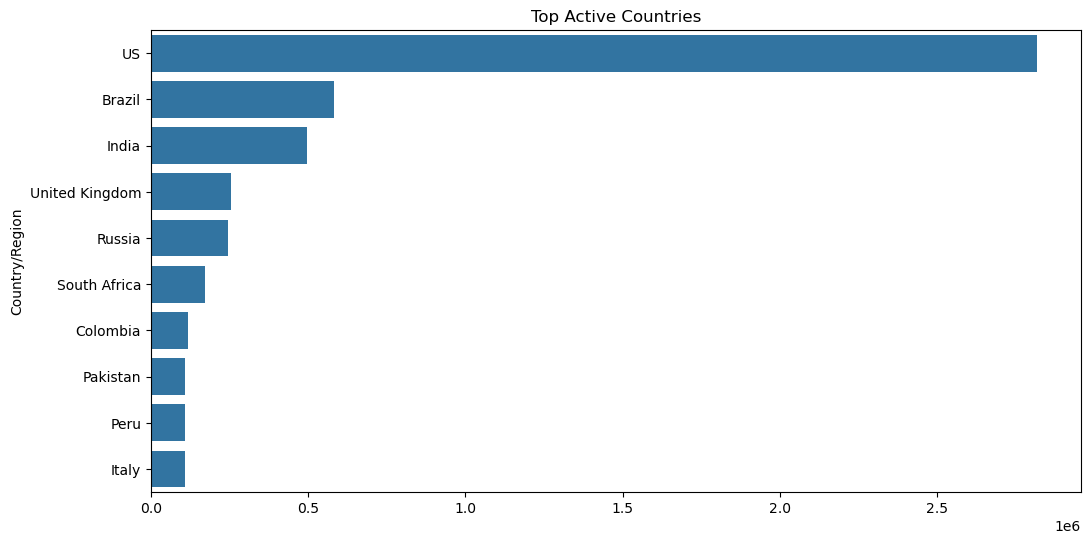

In [1]:
# ==========================================
# COVID EDA PROJECT
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs(
    "../../../datasets/cleaned/covid",
    exist_ok=True
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    "../../../datasets/raw/covid/covid_19_clean_complete.csv"
)

print(df.head())

# ==========================================
# BASIC INFO
# ==========================================

print("\nSHAPE")
print(df.shape)

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# CLEANING
# ==========================================

df = df.drop_duplicates()

df["Province/State"] = df[
    "Province/State"
].fillna("Unknown")

# ==========================================
# SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "../../../datasets/cleaned/covid/cleaned_covid.csv",
    index=False
)

# ==========================================
# TOTAL CASES BY COUNTRY
# ==========================================

country_cases = df.groupby(
    "Country/Region"
)["Confirmed"].max().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_cases.values,
    y=country_cases.index
)

plt.title("Top Countries by Cases")

plt.show()

# ==========================================
# DAILY CONFIRMED CASES
# ==========================================

daily_cases = df.groupby(
    "Date"
)["Confirmed"].sum()

plt.figure(figsize=(14,6))

plt.plot(
    daily_cases.index,
    daily_cases.values
)

plt.xticks(rotation=45)

plt.title("Daily Confirmed Cases")

plt.show()

# ==========================================
# DEATHS VS RECOVERED
# ==========================================

totals = df.groupby("Date")[[
    "Deaths",
    "Recovered"
]].sum()

plt.figure(figsize=(12,6))

plt.plot(
    totals.index,
    totals["Deaths"],
    label="Deaths"
)

plt.plot(
    totals.index,
    totals["Recovered"],
    label="Recovered"
)

plt.legend()

plt.xticks(rotation=45)

plt.title("Deaths vs Recovered")

plt.show()

# ==========================================
# TOP ACTIVE COUNTRIES
# ==========================================

df["Active"] = (
    df["Confirmed"]
    - df["Deaths"]
    - df["Recovered"]
)

active_cases = df.groupby(
    "Country/Region"
)["Active"].max().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=active_cases.values,
    y=active_cases.index
)

plt.title("Top Active Countries")

plt.show()

# ==========================================
# END
# ==========================================